In [1]:
import numpy as np
import discretize
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../../../../"))

from Forward.MT3D import compute_mt_impedance_tipper
from Forward.utils import apparent_resistivity
from Forward.utils import phase_deg
from discretize import TensorMesh


write_output = False

import torch

In [2]:
# 1) Modelo (Δσ)
# El NPY trae contraste de conductividad Δσ en S/m 

# Frecuencias en las que se va a hacer el modelado
frequency_list = np.logspace(-4, 2, 3)

# Ubicación del receptor para el modelado
receivers = np.array([
    [0.0, 0.0, -53.7]
])

# Carga de la malla usada para el modelo 3D de conductividad 
mesh = discretize.utils.load_mesh("../../../../models/Toy6/mesh_Toy6_MT.json")

# Carga del modelo 3D de conductividad
sigma = np.load("../../../../models/Toy6/model_Toy6_MT.npy", allow_pickle=True)

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)
print("frequency_list =", frequency_list)
print("receivers =", receivers)

mesh = 
  TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00


mesh.nC= 27000
mesh.nEx= 28830
mesh.nEy= 28830
mesh.nEz= 28830
frequency_list = [1.e-04 1.e-01 1.e+02]
receivers = [[  0.    0.  -53.7]]


In [3]:
mesh

TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00

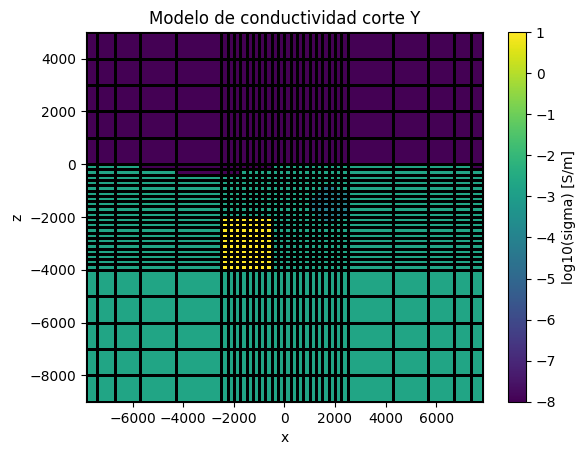

In [4]:
# 2) Plot del modelo de conductividad 3D
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="Y")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte Y")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

In [ ]:
# 3) Forward
Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequency_list)

## Se guardan el tensor de impedancias y el tipper
np.save("impedance_Toy6.npy", Z)
np.save("tipper_Toy6.npy", T)

## Se imprimen los resultados obtenidos
print("Computed shapes -> Z:", Z.shape, "T:", T.shape)

for i, r in enumerate(receivers):
    for j, f in enumerate(frequency_list):
        print(
            f"Rec {i} {r}, f={f} Hz -> "
            f"Zxy={Z[i,j,0,1]:.4e}, Zyx={Z[i,j,1,0]:.4e}, "
            f"Tzx={T[i,j,0]:.4e}, Tzy={T[i,j,1]:.4e}"
        )

Resolviendo para la frecuencia 0 de 3


In [ ]:
# Resistividad y fase aparente 
## Tensor de impedancias
Zxx = Z[:, :, 0, 0]
Zxy = Z[:, :, 0, 1]
Zyx = Z[:, :, 1, 0]
Zyy = Z[:, :, 1, 1]

rhoxx = apparent_resistivity(Zxx, frequency_list)
rhoxy = apparent_resistivity(Zxy, frequency_list)
rhoyx = apparent_resistivity(Zyx, frequency_list)
rhoyy = apparent_resistivity(Zyy, frequency_list)

phixx = phase_deg(Zxx)
phixy = phase_deg(Zxy)
phiyx = phase_deg(Zyx)
phiyy = phase_deg(Zyy)

# Tipper
Tzx=T[:,:,0]
Tzy=T[:,:,1]

Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

print("Zxy:", Z[:, :, 0, 1])
print("Zyx:", Z[:, :, 1, 0])
print("Zxx:", Z[:, :, 0, 0])
print("Zyy:", Z[:, :, 1, 1])
print("Tzx:", T[:, :, 0])
print("Tzy:", T[:, :, 1])
print("|Tzx|:", Tmzx[:])
print("|Tzy|:", Tmzy[:])
print("Tzx°:", Tpzx[:])
print("Tzy°:", Tpzy[:])

Zxy: [[-0.00079318-0.0007829j  -0.02352551-0.01624548j -0.48113682-0.34931574j]]
Zyx: [[0.00081523+0.0008051j  0.02430261+0.01723797j 0.54404114+0.38237365j]]
Zxx: [[-17.42963083+0.04657129j -16.59691686+0.69464637j
  -11.27099603-2.69032332j]]
Zyy: [[11.43839816-0.01369189j 11.03235168-0.33412155j 13.86289405+3.35790716j]]
Tzx: [[ 2.28304212e-05+1.31807991e-06j -9.05146304e-03-7.44436590e-03j
   9.65979167e-02+2.94217636e-03j]]
Tzy: [[0.00023833+0.00023522j 0.00708974+0.00476601j 0.0711994 -0.00416339j]]
|Tzx|: [[  0.6623435  173.95272541  11.82901251]]
|Tzy|: [[142.01219339  92.42941417   6.44236579]]
Tzx°: [[   3.30421744 -140.56444939    1.74457374]]
Tzy°: [[44.62382429 33.91059836 -3.3465636 ]]


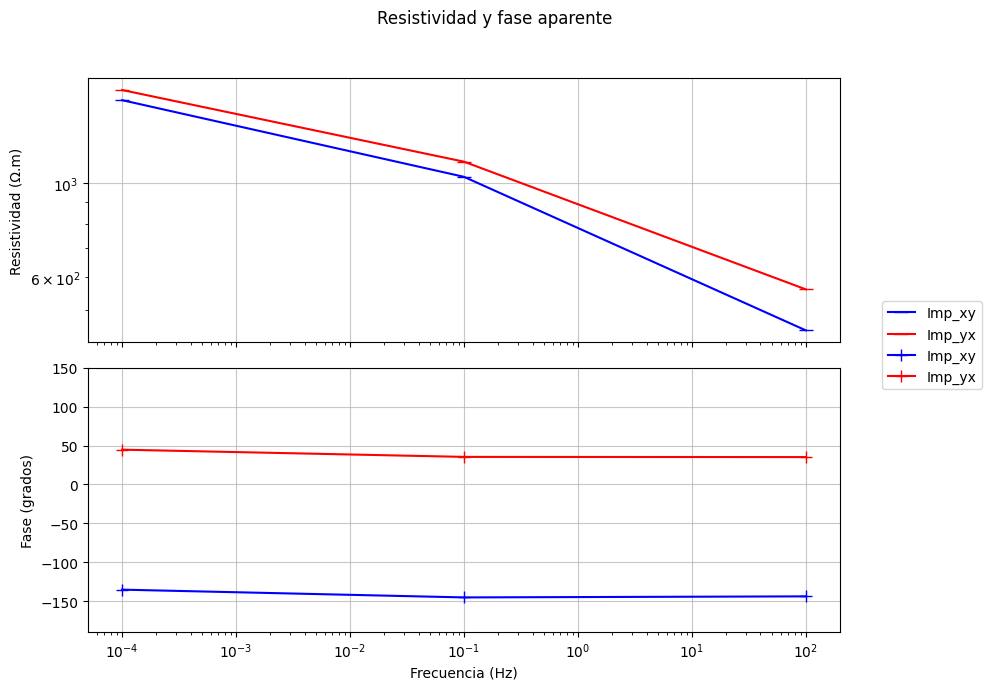

In [ ]:
# 4) Plot 
#  Resistividad y fase aparente
frec = frequency_list

# Receptor a graficar
irec = 0 

# Colores por componente
c_xx = "green"
c_xy = "blue"
c_yx = "red"
c_yy = "gold"

fig, (ax_rho, ax_phi) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Resistividad
ax_rho.plot(frec, rhoxy[irec, :], marker="_", linestyle="-", color=c_xy, markersize=10, label="Imp_xy")
ax_rho.plot(frec, rhoyx[irec, :], marker="_", linestyle="-", color=c_yx, markersize=10, label="Imp_yx")

ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad (Ω.m)")
ax_rho.grid(True, which="major", alpha=0.7)

# Fase
ax_phi.plot(frec, phixy[irec, :], marker="+", linestyle="-", color=c_xy, markersize=8, label="Imp_xy")
ax_phi.plot(frec, phiyx[irec, :], marker="+", linestyle="-", color=c_yx, markersize=8, label="Imp_yx")

ax_phi.set_xscale("log")
ax_phi.set_xlabel("Frecuencia (Hz)")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 150)

handles_rho, labels_rho = ax_rho.get_legend_handles_labels()
handles_phi, labels_phi = ax_phi.get_legend_handles_labels()

fig.legend(
    handles_rho + handles_phi,
    labels_rho + labels_phi,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle(f"Resistividad y fase aparente")

plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.savefig(f"Modeling_Toy6.png", dpi=300)
plt.show()


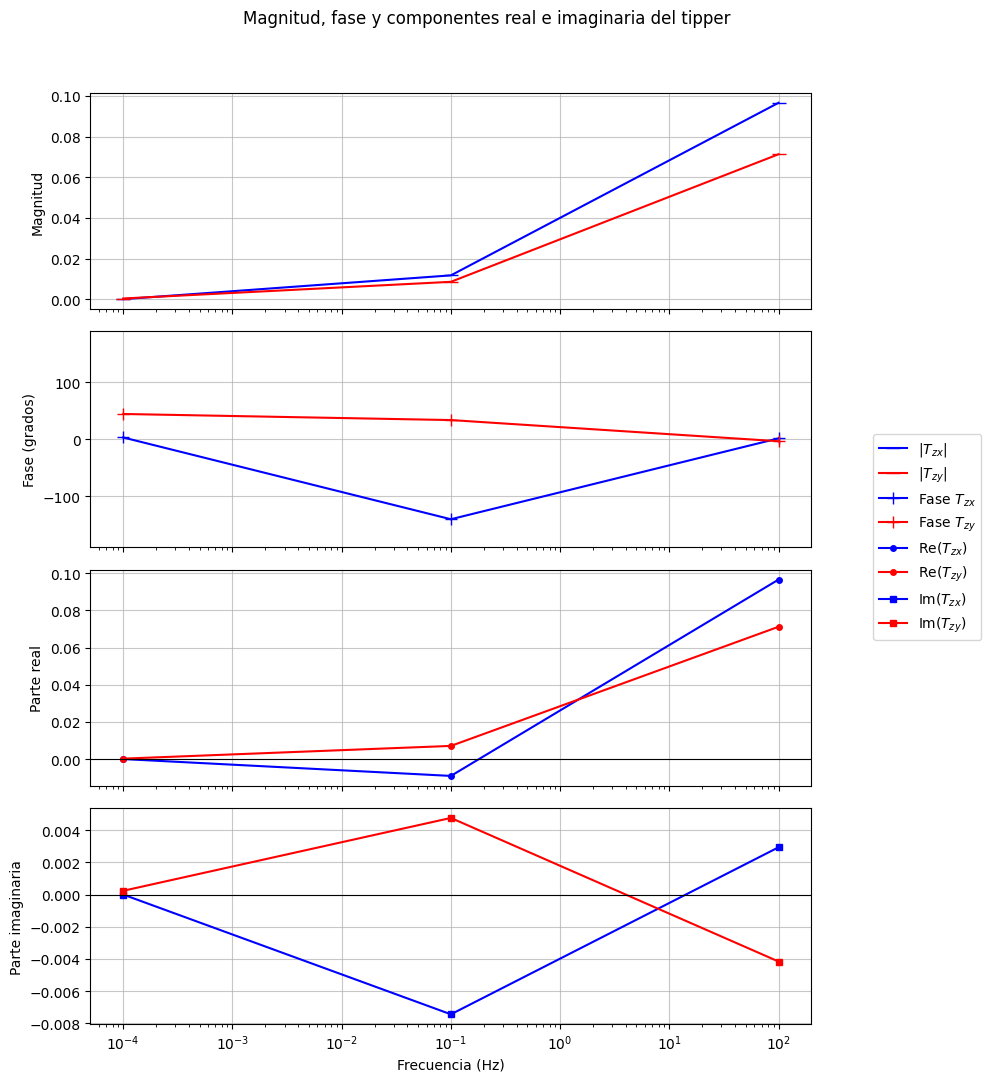

In [ ]:
# Magnitud, fase, parte real e imaginaria del tipper
Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

Tzx_real = np.real(Tzx)
Tzx_imag = np.imag(Tzx)

Tzy_real = np.real(Tzy)
Tzy_imag = np.imag(Tzy)

frec = frequency_list
irec = 0

# Colores por componente
c_tzx = "blue"
c_tzy = "red"

fig, (ax_mag, ax_phi, ax_real, ax_imag) = plt.subplots(
    4, 1,
    figsize=(10, 11),
    sharex=True
)

# Magnitud del tipper
ax_mag.plot(
    frec, Tmzx[irec, :],
    marker="_", linestyle="-",
    color=c_tzx, markersize=10,
    label=r"$|T_{zx}|$"
)

ax_mag.plot(
    frec, Tmzy[irec, :],
    marker="_", linestyle="-",
    color=c_tzy, markersize=10,
    label=r"$|T_{zy}|$"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="major", alpha=0.7)

# Fase del tipper
ax_phi.plot(
    frec, Tpzx[irec, :],
    marker="+", linestyle="-",
    color=c_tzx, markersize=8,
    label=r"Fase $T_{zx}$"
)

ax_phi.plot(
    frec, Tpzy[irec, :],
    marker="+", linestyle="-",
    color=c_tzy, markersize=8,
    label=r"Fase $T_{zy}$"
)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 190)

# Parte real
ax_real.plot(
    frec, Tzx_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Re($T_{zx}$)"
)

ax_real.plot(
    frec, Tzy_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Re($T_{zy}$)"
)

ax_real.set_xscale("log")
ax_real.set_ylabel("Parte real")
ax_real.grid(True, which="major", alpha=0.7)
ax_real.axhline(0, color="black", linewidth=0.8)

# Parte imaginaria
ax_imag.plot(
    frec, Tzx_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Im($T_{zx}$)"
)

ax_imag.plot(
    frec, Tzy_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Im($T_{zy}$)"
)

ax_imag.set_xscale("log")
ax_imag.set_xlabel("Frecuencia (Hz)")
ax_imag.set_ylabel("Parte imaginaria")
ax_imag.grid(True, which="major", alpha=0.7)
ax_imag.axhline(0, color="black", linewidth=0.8)


handles, labels = [], []

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle("Magnitud, fase y componentes real e imaginaria del tipper")

plt.tight_layout(rect=[0, 0, 0.84, 0.95])
plt.savefig("Tipper_ModelingToy6.png", dpi=300)
plt.show()